# Knowledge Distillation: Mistral-7B-Instruct → GPT-2 (124M)

**Teacher:** `mistralai/Mistral-7B-Instruct-v0.2` (loaded in 4-bit so it fits on a free Colab T4)
**Student:** `gpt2` (124M parameters)
**Method:** logit distillation (KL divergence on softened teacher/student distributions) + standard next-token cross-entropy

### Important: the two models do NOT share a tokenizer
GPT-2 has a 50,257-token byte-level BPE vocab; Mistral has a 32,000-token SentencePiece vocab. Plain logit distillation needs a 1:1 token mapping, so this notebook does the following:

1. **Shared vocabulary** – find tokens whose text is identical in both vocabs and distil only over those (renormalised).
2. **Character-boundary alignment** – a student position is distilled only if the teacher's tokenisation also has a token boundary at that exact character, so both models are predicting "the next token starting at the same place".
3. Cross-entropy on the true next token is applied at *every* position, so unaligned positions still get a learning signal.

### Before you run
* Runtime → Change runtime type → **GPU (T4 is enough)**.
* Add your token as a Colab secret named `HF_TOKEN` (key icon in the left sidebar, enable notebook access) — or paste it when prompted. The token needs **write** access.
* Accept the Mistral license on its Hugging Face model page (some Mistral versions are gated).
* The notebook is resumable: if Colab disconnects, re-run all cells and training continues from the latest checkpoint (kept on Google Drive).

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes datasets huggingface_hub matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.1 MB/s eta 0:00:00


## 1. Config & imports

In [ ]:
import os, re, json, glob, math, random, time
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ============================ CONFIG ============================
STUDENT_ID    = "gpt2"                                   # 124M
TEACHER_ID    = "mistralai/Mistral-7B-Instruct-v0.2"
HUB_REPO_NAME = "gpt2-124m-distilled-from-mistral7b"     # created under your HF username
PRIVATE_REPO  = False
USE_DRIVE     = True     # keep checkpoints on Google Drive so they survive disconnects
TEACHER_4BIT  = True     # False = fp16 teacher (needs ~16GB+ free VRAM, e.g. A100/L4)

# data
DATASET_NAME = "Salesforce/wikitext"
DATASET_CONFIG = "wikitext-2-raw-v1"# try "wikitext-103-raw-v1" for more data
MAX_CHARS         = 600      # max characters per training passage
MAX_LEN           = 128      # max GPT-2 tokens per passage
NUM_TRAIN_SAMPLES = 30000    # cap on passages

# optimisation
BATCH_SIZE   = 8
GRAD_ACCUM   = 2             # effective batch = 16
LR           = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 100
MAX_STEPS    = 2000          # optimiser steps (each = GRAD_ACCUM micro-batches)

# distillation
TEMPERATURE = 2.0
ALPHA       = 0.5            # loss = ALPHA * KD + (1 - ALPHA) * CE

# logging / checkpointing
LOG_EVERY  = 20
SAVE_EVERY = 250
KEEP_CKPTS = 2
SEED       = 42
# ================================================================

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
assert torch.cuda.is_available(), "No GPU found. Runtime -> Change runtime type -> GPU"
device = "cuda"
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


## 2. Log in to Hugging Face & create the model repo

In [ ]:
from huggingface_hub import login, HfApi

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None
if not HF_TOKEN:
    from getpass import getpass
    HF_TOKEN = getpass("Paste your Hugging Face token (needs write access): ")

login(token=HF_TOKEN)
api = HfApi(token=HF_TOKEN)
username = api.whoami()["name"]
REPO_ID = f"{username}/{HUB_REPO_NAME}"
api.create_repo(REPO_ID, repo_type="model", private=PRIVATE_REPO, exist_ok=True)
print("Logged in as:", username)
print("Model repo  :", f"https://huggingface.co/{REPO_ID}")

Logged in as: Sahilkumarr
Model repo  : https://huggingface.co/Sahilkumarr/gpt2-124m-distilled-from-mistral7b


In [ ]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK_DIR = "/content/drive/MyDrive/gpt2_distill"
else:
    WORK_DIR = "/content/gpt2_distill"

CKPT_DIR  = f"{WORK_DIR}/checkpoints"
FINAL_DIR = f"{WORK_DIR}/final_model"
for d in (WORK_DIR, CKPT_DIR, FINAL_DIR):
    os.makedirs(d, exist_ok=True)
print("Working dir:", WORK_DIR)

Mounted at /content/drive
Working dir: /content/drive/MyDrive/gpt2_distill


## 3. Download GPT-2 (student)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup

g_tok = AutoTokenizer.from_pretrained(STUDENT_ID)
g_tok.pad_token = g_tok.eos_token
student = AutoModelForCausalLM.from_pretrained(STUDENT_ID).to(device)

n_params = sum(p.numel() for p in student.parameters())
print(f"Student: {STUDENT_ID} | {n_params/1e6:.1f}M parameters | vocab {len(g_tok)}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Student: gpt2 | 124.4M parameters | vocab 50257


## 4. Load Mistral-7B-Instruct (teacher)

In [ ]:
m_tok = AutoTokenizer.from_pretrained(TEACHER_ID)

if TEACHER_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    teacher = AutoModelForCausalLM.from_pretrained(
        TEACHER_ID, quantization_config=bnb_cfg, device_map={"": 0}, torch_dtype=torch.float16
    )
else:
    teacher = AutoModelForCausalLM.from_pretrained(
        TEACHER_ID, device_map={"": 0}, torch_dtype=torch.float16
    )

teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

print(f"Teacher: {TEACHER_ID} | vocab {len(m_tok)} | logits dim {teacher.config.vocab_size}")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  493kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Teacher: mistralai/Mistral-7B-Instruct-v0.2 | vocab 32000 | logits dim 32000
GPU memory used: 4.6 GB


## 5. Data
WikiText passages, cleaned of the WikiText tokenisation artefacts (` @-@ `, spaces before punctuation) and reduced to ASCII.
ASCII-only text keeps character offsets identical to byte offsets, which makes the tokenizer alignment exact.

In [ ]:
from datasets import load_dataset

def clean(t):
    t = t.replace(" @-@ ", "-").replace(" @,@ ", ",").replace(" @.@ ", ".")
    t = re.sub(r" ([,.;:!?%)\]}])", r"\1", t)
    t = re.sub(r"([(\[{$]) ", r"\1", t)
    t = t.replace(" 's", "'s").replace(" n't", "n't").replace(" 're", "'re").replace(" 've", "'ve")
    t = t.encode("ascii", "ignore").decode()
    return re.sub(r"\s+", " ", t).strip()

def build_chunks(ds, max_chars, min_chars=200):
    chunks = []
    for row in ds:
        t = row["text"]
        if not t.strip() or t.lstrip().startswith("="):     # skip blanks & headings
            continue
        t = clean(t)
        while len(t) >= min_chars:
            if len(t) <= max_chars:
                chunks.append(t); break
            cut = t.rfind(" ", 0, max_chars)
            if cut <= 0: cut = max_chars
            chunks.append(t[:cut]); t = t[cut + 1:]
    return chunks

raw = load_dataset(DATASET_NAME, DATASET_CONFIG)
train_texts = build_chunks(raw["train"], MAX_CHARS)
random.Random(SEED).shuffle(train_texts)
train_texts = train_texts[:NUM_TRAIN_SAMPLES]

# eval text (test split), same cleaning so before/after are comparable
test_paras = [clean(r["text"]) for r in raw["test"] if r["text"].strip() and not r["text"].lstrip().startswith("=")]
test_text = " ".join(test_paras)

print("train passages:", len(train_texts), "| test characters:", len(test_text))
print("\nExample:", train_texts[0][:300])

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

train passages: 19687 | test characters: 1220145

Example: second verse, in which all band members are hitting the drums simultaneously. " We hit anything we could hit at the same time... and it sounded kind of cool ", he said. Nils Trnqvist is credited for playing the drums, while David Lindberg, Jonathan Lundberg and Claes Malmberg played the military dru


## 6. Shared-vocabulary map between the two tokenizers

In [ ]:
def piece_to_str(piece):
    """Mistral (SentencePiece) piece -> the literal text it stands for (None if not plain ASCII text)."""
    m = re.fullmatch(r"<0x([0-9A-Fa-f]{2})>", piece)          # byte-fallback tokens
    if m:
        b = int(m.group(1), 16)
        return chr(b) if b < 128 else None
    return piece.replace("\u2581", " ")

# text of every token in each vocab
G_STR = [g_tok.decode([i], clean_up_tokenization_spaces=False) for i in range(len(g_tok))]

m_special = set(m_tok.all_special_ids)
M_STR = []
for i, p in enumerate(m_tok.convert_ids_to_tokens(list(range(len(m_tok))))):
    M_STR.append(None if (i in m_special or p is None) else piece_to_str(p))

m_lookup = {}
for i, s in enumerate(M_STR):
    if s:
        m_lookup.setdefault(s, i)

g_shared, m_shared = [], []
for gid, s in enumerate(G_STR):
    if gid == g_tok.eos_token_id or not s:
        continue
    if s in m_lookup:
        g_shared.append(gid); m_shared.append(m_lookup[s])

g_sh = torch.tensor(g_shared, device=device)
m_sh = torch.tensor(m_shared, device=device)
print(f"Shared tokens: {len(g_shared):,}  ({len(g_shared)/len(g_tok):.0%} of GPT-2 vocab, "
      f"{len(m_shared)/len(m_tok):.0%} of Mistral vocab)")

Shared tokens: 21,366  (43% of GPT-2 vocab, 67% of Mistral vocab)


## 7. Dataset with character-boundary alignment
For each passage we tokenise with both tokenizers. GPT-2 position `i` predicts the token that starts at character `G_end[i]`.
If the Mistral tokenisation also has a boundary at that character (token `k` ends there), then teacher position `k+1` (index shifted by BOS) predicts a token starting at the same place — that pair `(i, k+1)` is used for the KD loss.

In [ ]:
class DistillDataset(Dataset):
    def __init__(self, texts, max_len):
        self.texts, self.max_len = texts, max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        g_ids = g_tok(self.texts[idx], add_special_tokens=False)["input_ids"][: self.max_len]
        g_pieces = [G_STR[i] for i in g_ids]
        text = "".join(g_pieces)                                  # text actually covered by the kept GPT-2 tokens
        g_end = np.cumsum([len(p) for p in g_pieces])

        m_ids = m_tok(text)["input_ids"]                          # [BOS, ...]
        m_body = [M_STR[i] for i in m_ids[1:]]

        pairs_s, pairs_t = [], []
        if all(p is not None for p in m_body):
            concat = "".join(m_body)
            if concat == text:            off = 0
            elif concat[1:] == text:      off = 1                 # SentencePiece dummy-prefix space
            else:                         off = None
            if off is not None:
                lens = [len(p) for p in m_body]
                lens[0] -= off
                m_end = np.cumsum(lens)
                end2k = {int(e): k for k, e in enumerate(m_end)}
                for i in range(len(g_ids) - 1):
                    k = end2k.get(int(g_end[i]))
                    if k is not None and k < len(m_body) - 1:
                        pairs_s.append(i)
                        pairs_t.append(k + 1)                     # +1 because of BOS
        return {"g_ids": g_ids, "m_ids": m_ids, "pairs_s": pairs_s, "pairs_t": pairs_t}


G_PAD = g_tok.eos_token_id
M_PAD = m_tok.pad_token_id if m_tok.pad_token_id is not None else (m_tok.eos_token_id or 0)

def collate(batch):
    B = len(batch)
    Lg = max(len(b["g_ids"]) for b in batch)
    Lm = max(len(b["m_ids"]) for b in batch)
    g = torch.full((B, Lg), G_PAD, dtype=torch.long); g_mask = torch.zeros((B, Lg), dtype=torch.long)
    m = torch.full((B, Lm), M_PAD, dtype=torch.long); m_mask = torch.zeros((B, Lm), dtype=torch.long)
    bi, sp, tp = [], [], []
    for j, b in enumerate(batch):
        g[j, :len(b["g_ids"])] = torch.tensor(b["g_ids"]); g_mask[j, :len(b["g_ids"])] = 1
        m[j, :len(b["m_ids"])] = torch.tensor(b["m_ids"]); m_mask[j, :len(b["m_ids"])] = 1
        bi += [j] * len(b["pairs_s"]); sp += b["pairs_s"]; tp += b["pairs_t"]
    return {"g": g, "g_mask": g_mask, "m": m, "m_mask": m_mask,
            "b_idx": torch.tensor(bi, dtype=torch.long),
            "s_pos": torch.tensor(sp, dtype=torch.long),
            "t_pos": torch.tensor(tp, dtype=torch.long)}

train_ds = DistillDataset(train_texts, MAX_LEN)
loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
                    num_workers=2, drop_last=True)
print("batches per epoch:", len(loader))

batches per epoch: 2460


### Sanity check: is the alignment correct?
The teacher's top-1 prediction on aligned positions should match the real next token far more often than chance. If it doesn't, something is wrong with the alignment.

In [ ]:
batch = next(iter(loader))
b = {k: v.to(device) for k, v in batch.items()}

n_pos = int(b["g_mask"][:, 1:].sum())
print(f"Aligned positions: {b['b_idx'].numel()} / {n_pos} ({b['b_idx'].numel()/n_pos:.0%} of student positions get a KD target)")

with torch.no_grad():
    t_logits = teacher(input_ids=b["m"], attention_mask=b["m_mask"]).logits
    with torch.autocast("cuda", dtype=torch.float16):
        s_logits = student(input_ids=b["g"], attention_mask=b["g_mask"]).logits

    truth = b["g"][b["b_idx"], b["s_pos"] + 1]                                  # true next GPT-2 token
    t_pred = g_sh[t_logits[b["b_idx"], b["t_pos"]][:, m_sh].argmax(-1)]         # teacher top-1 (shared vocab)
    s_pred = g_sh[s_logits[b["b_idx"], b["s_pos"]][:, g_sh].argmax(-1)]         # student top-1 (shared vocab)

print(f"Teacher top-1 accuracy on aligned positions: {(t_pred == truth).float().mean():.1%}")
print(f"Student top-1 accuracy on aligned positions: {(s_pred == truth).float().mean():.1%}")
del t_logits, s_logits, b
torch.cuda.empty_cache()

Aligned positions: 663 / 667 (99% of student positions get a KD target)
Teacher top-1 accuracy on aligned positions: 36.7%
Student top-1 accuracy on aligned positions: 33.6%


## 8. Distillation loss

In [ ]:
def distill_loss(s_logits, t_logits, b):
    """
    total = ALPHA * T^2 * KL(teacher || student)   (aligned positions, shared vocab, temperature T)
          + (1 - ALPHA) * CE(student, true next token)   (all positions)
    """
    V = s_logits.size(-1)
    labels = b["g"].masked_fill(b["g_mask"] == 0, -100)
    ce = F.cross_entropy(s_logits[:, :-1].float().reshape(-1, V), labels[:, 1:].reshape(-1), ignore_index=-100)

    if b["b_idx"].numel() > 0:
        s = s_logits[b["b_idx"], b["s_pos"]][:, g_sh].float() / TEMPERATURE
        t = t_logits[b["b_idx"], b["t_pos"]][:, m_sh].float() / TEMPERATURE
        kd = F.kl_div(F.log_softmax(s, -1), F.log_softmax(t, -1), log_target=True, reduction="batchmean")
        kd = kd * TEMPERATURE ** 2
    else:
        kd = torch.zeros((), device=s_logits.device)

    return ALPHA * kd + (1 - ALPHA) * ce, kd.detach(), ce.detach()

## 9. Evaluation helpers + **BEFORE** distillation

In [ ]:
@torch.no_grad()
def eval_ppl(model, text, ctx=512, bs=8):
    """Perplexity on non-overlapping ctx-token windows."""
    model.eval()
    ids = g_tok(text, return_tensors="pt").input_ids[0]
    n = (len(ids) // ctx) * ctx
    windows = ids[:n].view(-1, ctx)
    nll, cnt = 0.0, 0
    for i in range(0, len(windows), bs):
        x = windows[i:i + bs].to(device)
        with torch.autocast("cuda", dtype=torch.float16):
            logits = model(input_ids=x).logits
        loss = F.cross_entropy(logits[:, :-1].float().reshape(-1, logits.size(-1)),
                               x[:, 1:].reshape(-1), reduction="sum")
        nll += loss.item(); cnt += x[:, 1:].numel()
    return math.exp(nll / cnt)

PROMPTS = [
    "The history of the Roman Empire began",
    "In machine learning, a neural network is",
    "The capital of France is",
    "Scientists have recently discovered that",
]

@torch.no_grad()
def generate_samples(model, prompts, max_new_tokens=50):
    model.eval()
    outs = []
    for p in prompts:
        enc = g_tok(p, return_tensors="pt").to(device)
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                             no_repeat_ngram_size=3, pad_token_id=g_tok.eos_token_id)
        outs.append(g_tok.decode(out[0], skip_special_tokens=True))
    return outs

before_path = f"{WORK_DIR}/metrics_before.json"
if os.path.exists(before_path):                       # cached from a previous session (pristine GPT-2)
    metrics_before = json.load(open(before_path))
else:
    metrics_before = {"test_ppl": eval_ppl(student, test_text), "samples": generate_samples(student, PROMPTS)}
    json.dump(metrics_before, open(before_path, "w"), indent=2)

print(f"BEFORE  | WikiText test perplexity: {metrics_before['test_ppl']:.2f}\n")
for s in metrics_before["samples"]:
    print("-", s.replace("\n", " "), "\n")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (262054 > 1024). Running this sequence through the model will result in indexing errors


BEFORE  | WikiText test perplexity: 28.98

- The history of the Roman Empire began in the fourth century B.C.E. with the arrival of the Emperor Constantine. The Emperor Constantine was the first Roman emperor to rule the empire. He was the son of the emperor Constantine, who was the second son of Constantine. He became 

- In machine learning, a neural network is a network of neurons that are connected to a network. The network is connected to the network by a process called a "supervised learning" process.  The process is called "superposition," and it involves a process of learning and memory. 

- The capital of France is the capital of the French Republic, and the capital is the city of Paris. The capital of Europe is the European Union. The European Union is the Union of the European States. The Union of Europe consists of the United States of America, the European 

- Scientists have recently discovered that the brain of a human with autism is more complex than previously thought.

## 10. Train (with checkpointing + auto-resume)
Checkpoints (model, optimiser, scheduler, AMP scaler, step, loss history) are written to `CKPT_DIR` every `SAVE_EVERY` steps.
Re-running this cell after a disconnect resumes from the newest one.

In [ ]:
optimizer = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(optimizer, WARMUP_STEPS, MAX_STEPS)
scaler = torch.amp.GradScaler("cuda")

history = {"step": [], "loss": [], "kd": [], "ce": [], "lr": []}
global_step = 0

def list_ckpts():
    files = glob.glob(f"{CKPT_DIR}/step_*.pt")
    return sorted(files, key=lambda p: int(re.findall(r"step_(\d+)\.pt", p)[0]))

def save_ckpt(step):
    path = f"{CKPT_DIR}/step_{step}.pt"
    torch.save({"step": step, "model": student.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(), "history": history},
               path + ".tmp")
    os.replace(path + ".tmp", path)
    for old in list_ckpts()[:-KEEP_CKPTS]:
        os.remove(old)
    print(f"  [checkpoint saved: {path}]")

ckpts = list_ckpts()
if ckpts:
    ck = torch.load(ckpts[-1], map_location=device, weights_only=False)
    student.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"]); scaler.load_state_dict(ck["scaler"])
    history, global_step = ck["history"], ck["step"]
    print(f"Resumed from {ckpts[-1]} (step {global_step})")
else:
    print("No checkpoint found - starting from pretrained GPT-2")

def next_batch(it):
    try:
        return next(it), it
    except StopIteration:
        it = iter(loader)
        return next(it), it

student.train()
data_iter = iter(loader)
window = {"loss": 0.0, "kd": 0.0, "ce": 0.0, "n": 0}
pbar = tqdm(total=MAX_STEPS, initial=global_step, desc="distilling")

try:
    while global_step < MAX_STEPS:
        optimizer.zero_grad(set_to_none=True)
        for _ in range(GRAD_ACCUM):
            batch, data_iter = next_batch(data_iter)
            b = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

            with torch.no_grad():
                t_logits = teacher(input_ids=b["m"], attention_mask=b["m_mask"]).logits
            with torch.autocast("cuda", dtype=torch.float16):
                s_logits = student(input_ids=b["g"], attention_mask=b["g_mask"]).logits

            loss, kd, ce = distill_loss(s_logits, t_logits, b)
            scaler.scale(loss / GRAD_ACCUM).backward()

            window["loss"] += loss.item() / GRAD_ACCUM
            window["kd"] += kd.item() / GRAD_ACCUM
            window["ce"] += ce.item() / GRAD_ACCUM

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()

        global_step += 1; window["n"] += 1
        pbar.update(1)

        if global_step % LOG_EVERY == 0:
            n = window["n"]
            history["step"].append(global_step)
            history["loss"].append(window["loss"] / n)
            history["kd"].append(window["kd"] / n)
            history["ce"].append(window["ce"] / n)
            history["lr"].append(scheduler.get_last_lr()[0])
            pbar.set_postfix(loss=f"{history['loss'][-1]:.3f}", kd=f"{history['kd'][-1]:.3f}", ce=f"{history['ce'][-1]:.3f}")
            window = {"loss": 0.0, "kd": 0.0, "ce": 0.0, "n": 0}

        if global_step % SAVE_EVERY == 0:
            save_ckpt(global_step)

except KeyboardInterrupt:
    print("Interrupted - saving checkpoint before exiting")
    save_ckpt(global_step)
    raise

pbar.close()
save_ckpt(global_step)
json.dump(history, open(f"{WORK_DIR}/loss_history.json", "w"))
print("Training finished at step", global_step)

No checkpoint found - starting from pretrained GPT-2


distilling:   0%|          | 0/2000 [00:00<?, ?it/s]

/tmp/ipykernel_1485/2329828439.py:65: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(optimizer); scaler.update(); scheduler.step()


  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_250.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_500.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_750.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_1000.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_1250.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_1500.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_1750.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_2000.pt]
  [checkpoint saved: /content/drive/MyDrive/gpt2_distill/checkpoints/step_2000.pt]
Training finished at step 2000


## 11. Plot training loss

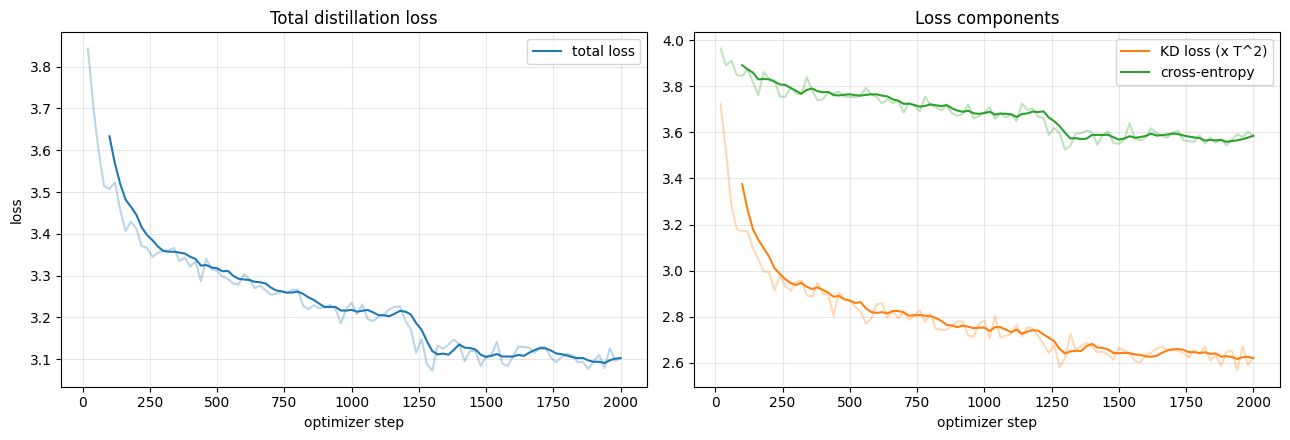

In [ ]:
def smooth(y, k=5):
    if len(y) < k: return np.array(y)
    return np.convolve(y, np.ones(k) / k, mode="valid")

steps = np.array(history["step"])
k = 5
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(steps, history["loss"], alpha=0.3, color="C0")
ax[0].plot(steps[k - 1:] if len(steps) >= k else steps, smooth(history["loss"], k), color="C0", label="total loss")
ax[0].set_title("Total distillation loss"); ax[0].set_xlabel("optimizer step"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)

for name, c in (("kd", "C1"), ("ce", "C2")):
    ax[1].plot(steps, history[name], alpha=0.3, color=c)
    ax[1].plot(steps[k - 1:] if len(steps) >= k else steps, smooth(history[name], k), color=c,
               label="KD loss (x T^2)" if name == "kd" else "cross-entropy")
ax[1].set_title("Loss components"); ax[1].set_xlabel("optimizer step"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plot_path = f"{FINAL_DIR}/training_loss.png"
plt.savefig(plot_path, dpi=150)
plt.show()

## 12. Evaluate **AFTER** distillation

In [ ]:
metrics_after = {"test_ppl": eval_ppl(student, test_text), "samples": generate_samples(student, PROMPTS)}

print(f"WikiText test perplexity | before: {metrics_before['test_ppl']:.2f}  ->  after: {metrics_after['test_ppl']:.2f}\n")
for p, b_txt, a_txt in zip(PROMPTS, metrics_before["samples"], metrics_after["samples"]):
    print("PROMPT :", p)
    print("BEFORE :", b_txt.replace("\n", " "))
    print("AFTER  :", a_txt.replace("\n", " "))
    print()

WikiText test perplexity | before: 28.98  ->  after: 29.64

PROMPT : The history of the Roman Empire began
BEFORE : The history of the Roman Empire began in the fourth century B.C.E. with the arrival of the Emperor Constantine. The Emperor Constantine was the first Roman emperor to rule the empire. He was the son of the emperor Constantine, who was the second son of Constantine. He became
AFTER  : The history of the Roman Empire began in the late 12th century with the arrival of the emperor Constantine, who was the first emperor to rule the Roman empire. Constantine was the son of the god Mithras, who had been the first to rule a Roman empire in the Roman period.

PROMPT : In machine learning, a neural network is
BEFORE : In machine learning, a neural network is a network of neurons that are connected to a network. The network is connected to the network by a process called a "supervised learning" process.  The process is called "superposition," and it involves a process of learning an

## 13. Save the final model & upload to the Hugging Face Hub

In [ ]:
student.eval()
student.save_pretrained(FINAL_DIR, safe_serialization=True)
g_tok.save_pretrained(FINAL_DIR)

train_cfg = dict(student=STUDENT_ID, teacher=TEACHER_ID, teacher_4bit=TEACHER_4BIT,
                 dataset=f"{DATASET_NAME}/{DATASET_CONFIG}", num_train_passages=len(train_texts),
                 max_len=MAX_LEN, batch_size=BATCH_SIZE, grad_accum=GRAD_ACCUM, lr=LR, weight_decay=WEIGHT_DECAY,
                 warmup_steps=WARMUP_STEPS, steps=global_step, temperature=TEMPERATURE, alpha=ALPHA,
                 shared_vocab_tokens=len(g_shared), seed=SEED)
json.dump(train_cfg, open(f"{FINAL_DIR}/training_config.json", "w"), indent=2)
json.dump({"before": metrics_before, "after": metrics_after}, open(f"{FINAL_DIR}/metrics.json", "w"), indent=2)
json.dump(history, open(f"{FINAL_DIR}/loss_history.json", "w"))

model_card = f"""---
license: mit
base_model: openai-community/gpt2
datasets:
- {DATASET_NAME}
tags:
- knowledge-distillation
- gpt2
- text-generation
---

# {HUB_REPO_NAME}

GPT-2 (124M) distilled from **{TEACHER_ID}** with logit distillation.

## Method
* Loss = {ALPHA} x T^2 x KL(teacher || student) + {1 - ALPHA} x cross-entropy, temperature T = {TEMPERATURE}
* The tokenizers differ (GPT-2: 50,257 tokens, Mistral: 32,000), so the KL term is computed only over the
  {len(g_shared):,} tokens whose text is identical in both vocabularies (renormalised), and only at positions where
  both tokenizers have a token boundary at the same character.
* Teacher loaded in {"4-bit NF4" if TEACHER_4BIT else "fp16"}. Data: {DATASET_NAME}/{DATASET_CONFIG} ({len(train_texts):,} passages), {global_step} optimizer steps.

## Results (WikiText-2 test, cleaned text, 512-token windows)
| | Perplexity |
|---|---|
| GPT-2 before distillation | {metrics_before['test_ppl']:.2f} |
| After distillation | {metrics_after['test_ppl']:.2f} |

![training loss](training_loss.png)

## Usage
```python
from transformers import AutoTokenizer, AutoModelForCausalLM
tok = AutoTokenizer.from_pretrained("{REPO_ID}")
model = AutoModelForCausalLM.from_pretrained("{REPO_ID}")
```
"""
open(f"{FINAL_DIR}/README.md", "w").write(model_card)

api.upload_folder(repo_id=REPO_ID, repo_type="model", folder_path=FINAL_DIR,
                  commit_message="Upload GPT-2 124M distilled from Mistral-7B-Instruct")
print("Uploaded ->", f"https://huggingface.co/{REPO_ID}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Uploaded -> https://huggingface.co/Sahilkumarr/gpt2-124m-distilled-from-mistral7b


In [ ]:
# Verify: pull the model back from the Hub and generate
check_model = AutoModelForCausalLM.from_pretrained(REPO_ID).to(device)
check_tok = AutoTokenizer.from_pretrained(REPO_ID)
enc = check_tok("The future of artificial intelligence", return_tensors="pt").to(device)
out = check_model.generate(**enc, max_new_tokens=40, do_sample=False, no_repeat_ngram_size=3,
                           pad_token_id=check_tok.eos_token_id)
print(check_tok.decode(out[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/961 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/326 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

The future of artificial intelligence is uncertain. The most likely future is a future in which humans will be able to do things like create and manipulate objects, and to do so without the need for human intervention. The future of AI


## Notes & tuning tips
* **Out of memory?** Lower `BATCH_SIZE` (and raise `GRAD_ACCUM`), or lower `MAX_LEN`.
* **Too slow?** The teacher forward pass dominates. Reduce `MAX_STEPS`, or use `TEACHER_4BIT=False` on an A100/L4 for faster teacher inference.
* **More gain:** use `wikitext-103-raw-v1`, raise `MAX_STEPS`, or swap in your own domain text – distillation works best on data that resembles what you'll use the student for.
* **Instruct teacher, base student:** Mistral-Instruct is chat-tuned, so its distribution on raw web text is a bit sharper than a base model's. `TEMPERATURE` of 2–4 helps soften this.
* **Shared vocab:** the KD term drops tokens that exist in only one tokenizer (mostly rare/multi-byte pieces), so the distilled signal covers the common, mostly-ASCII part of the vocab.